## Demo embedding extraction

This notebook shows how to use the embedding extraction module for generating numerical representation using the pre-trained models.

The following family of pre-trained models is available for testing

- Prot5Based
- ESMBasedEmbedding
- Ankh2BasedEmbedding
- BertBasedMebedding
- MistralBasedEmbedding

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import sys
sys.path.insert(0, "../../utils/")

In [3]:
import pandas as pd

- Loading modules

In [4]:
from embedding_extraction.prot5_based import Prot5Based
from embedding_extraction.esm_based import ESMBasedEmbedding
from embedding_extraction.bert_based import BertBasedMebedding
from embedding_extraction.mistral_based import MistralBasedEmbedding
from dimensionality_reductions.non_linear_reductions import NonLinearReductions

In [5]:
import seaborn as sns

- Read AMP dataset and select only 10 examples

In [6]:
name_data = "antiviral_homology_90_Q"
df_data = pd.read_csv(f"../../data/{name_data}.csv")

df_data.head(5)

,sequence,experimental_characteristics,target,length_sequence
0,CAVACELKWESEFWRWTE,Mammalian,4320.0,18
1,CDVIALLACHLNT,Mammalian,4320.0,13
2,CDVIALLCHLNTPSFNTTHYRESWY,Mammalian,4320.0,25
3,CEEIRARLSTHLRKMRKRLMRDADDLQKRLAVY,Mammalian,4320.0,33
4,CEELRVRLASHLRKLRKRLLRDADDLQKRLAVY,Mammalian,4320.0,33


In [7]:
df_data.drop(columns=["length_sequence"], inplace=True)
df_data

,sequence,experimental_characteristics,target
0,CAVACELKWESEFWRWTE,Mammalian,4320.0
1,CDVIALLACHLNT,Mammalian,4320.0
2,CDVIALLCHLNTPSFNTTHYRESWY,Mammalian,4320.0
3,CEEIRARLSTHLRKMRKRLMRDADDLQKRLAVY,Mammalian,4320.0
4,CEELRVRLASHLRKLRKRLLRDADDLQKRLAVY,Mammalian,4320.0
...,...,...,...
712,YQVVKQPDYLLVPEEVMEYK,E_coli,7200.0
713,YRWWRWARRWYRWWRWARRW,E_coli,7200.0
714,YTMLVVDDL,E_coli,7200.0
715,YTSLIHSLIEEAQNQQEKNEQELLELDKWASLWNWF,E_coli,7200.0


### ProT5 evaluation

In [ ]:
df_to_prot5 = df_data.copy()
df_to_prot5["sequence"] = df_to_prot5["sequence"].apply(lambda x: " ".join(x)) # this process is necessary for the application of the pre-trained model

prot5_based = Prot5Based(
    name_device="cuda",
    dataset=df_to_prot5,
    name_model="Rostlab/ProstT5",
    name_tokenizer="Rostlab/ProstT5",
    column_seq="sequence",
    columns_ignore=["target","experimental_characteristics"],
)

print("Loading model/tokenizer")
prot5_based.load_model_tokenizer()

print("Generating embedding")
df_embedding = prot5_based.embedding_process(batch_size=5)
df_embedding.to_csv(f"../../data/numerical_rep_reg/{name_data}_prot5_embedding.csv", index=False)
prot5_based.cleaning_memory()
print("Process finished")

df_embedding

Using device:  cuda
Loading model/tokenizer
Generating embedding


[+] Embedding: 100%|██████████| 144/144 [00:08<00:00, 17.26batch/s]


Empty cache memory
Process finished


,p_1,p_2,p_3,p_4,p_5,p_6,p_7,p_8,p_9,p_10,...,p_1017,p_1018,p_1019,p_1020,p_1021,p_1022,p_1023,p_1024,target,experimental_characteristics
0,0.007704,0.077512,-0.105592,-0.054378,-0.026292,0.052425,0.013635,0.113906,0.031978,-0.051761,...,0.114417,0.045548,0.114810,-0.045536,-0.009438,-0.165950,0.083435,-0.206973,4320.0,Mammalian
1,-0.041615,0.099891,-0.032804,-0.030124,-0.083731,-0.106589,-0.035553,0.033100,-0.033484,-0.062694,...,0.183255,0.042302,0.146488,-0.009817,0.129117,-0.040209,0.076646,0.031651,4320.0,Mammalian
2,-0.070016,0.165298,-0.055481,-0.033133,-0.017700,-0.013389,-0.029113,0.116394,-0.075322,-0.087759,...,0.056803,0.011371,0.066250,-0.013087,0.083106,0.001633,0.090386,-0.018226,4320.0,Mammalian
3,-0.205902,-0.058016,-0.052851,-0.035843,0.057577,-0.035720,-0.156341,0.144109,0.002374,-0.005200,...,0.017532,-0.015519,-0.044203,0.016102,0.177183,-0.137472,0.157548,-0.140340,4320.0,Mammalian
4,-0.209548,-0.039549,-0.085820,-0.013201,0.082494,-0.032959,-0.142535,0.158908,0.006158,-0.013377,...,0.008412,-0.011996,-0.053665,-0.020877,0.184626,-0.132172,0.153784,-0.109611,4320.0,Mammalian
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
712,-0.157828,0.080220,-0.134509,-0.024411,-0.009210,0.072394,-0.058482,0.053240,0.077066,0.084828,...,0.037505,0.081755,0.018977,0.136174,0.076199,-0.093582,0.033571,-0.195850,7200.0,E_coli
713,-0.137362,-0.114129,-0.120217,-0.007904,0.254243,-0.015313,-0.092671,0.073956,0.105611,-0.084017,...,0.003367,-0.034771,0.066850,-0.076335,0.196156,-0.066858,0.017583,-0.065644,7200.0,E_coli
714,0.019334,0.103498,-0.126487,0.015428,0.006212,-0.128878,-0.094910,0.012020,0.042245,0.169941,...,0.176792,-0.015274,0.152771,0.105824,0.209193,-0.243599,0.130593,-0.000998,7200.0,E_coli
715,-0.098615,-0.091629,-0.020671,-0.007833,0.059455,0.046928,-0.202553,0.034373,0.059682,0.020352,...,0.032902,0.001195,-0.016447,0.030442,0.086734,-0.125661,0.110023,-0.169574,7200.0,E_coli


<Axes: xlabel='p_1', ylabel='p_2'>

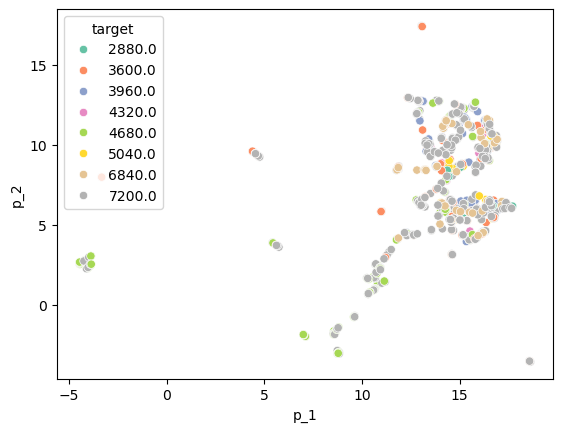

In [41]:
df_values = df_embedding.drop(columns=["target", "experimental_characteristics"])
nonlinear_instance = NonLinearReductions(dataset=df_values)

transform_values_umap = nonlinear_instance.applyUMAP()
transform_values_umap["target"] = df_embedding["target"].values

sns.scatterplot(data=transform_values_umap, x="p_1", y="p_2", hue="target", palette="Set2")


### ESM evaluation

In [9]:
esm_based = ESMBasedEmbedding(
    name_device="cpu",
    dataset=df_data,
    name_model="facebook/esm2_t36_3B_UR50D",
    name_tokenizer="facebook/esm2_t36_3B_UR50D",
    column_seq="sequence",
    columns_ignore=["target", "experimental_characteristics"],
)

print("Loading model/tokenizer")
esm_based.load_model_tokenizer()

print("Generating embedding")
df_embedding = esm_based.embedding_process(batch_size=5)
df_embedding.to_csv(f"../../data/numerical_rep_reg/{name_data}_esm2_t36_3B_UR50D_embedding.csv", index=False)

esm_based.cleaning_memory()
print("Process finished")

df_embedding

Using device:  cpu
Loading model/tokenizer


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 47.98it/s]
Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t36_3B_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Generating embedding


[+] Embedding: 100%|██████████| 144/144 [03:42<00:00,  1.54s/batch]


Empty cache memory
Process finished


,p_1,p_2,p_3,p_4,p_5,p_6,p_7,p_8,p_9,p_10,...,p_2553,p_2554,p_2555,p_2556,p_2557,p_2558,p_2559,p_2560,target,experimental_characteristics
0,0.075501,-0.025801,0.058795,-0.029096,-0.010737,-0.129753,-0.051396,0.014632,-0.017430,-0.004424,...,0.024553,-0.030067,0.038599,-0.101026,0.024546,-0.016613,-0.149187,-0.060304,4320.0,Mammalian
1,0.095646,0.007496,0.073478,-0.029764,-0.014421,-0.124197,-0.048067,0.023707,-0.020460,-0.004290,...,0.015399,0.000914,0.083371,-0.104949,0.045853,-0.061610,-0.119883,-0.043495,4320.0,Mammalian
2,0.052527,-0.037951,0.040664,-0.029947,0.029416,-0.103879,-0.039710,0.003720,0.018306,0.003059,...,-0.001750,-0.024378,0.077881,-0.135331,-0.007166,-0.014585,-0.201261,-0.009563,4320.0,Mammalian
3,0.081407,-0.067776,-0.006965,0.028313,0.014545,-0.029007,-0.003764,0.041679,-0.009373,0.009391,...,0.023884,-0.066188,0.014978,-0.055440,0.033215,-0.027986,0.006243,0.069741,4320.0,Mammalian
4,0.087039,-0.080171,0.008363,0.005970,-0.007219,-0.024116,-0.011221,-0.008428,-0.042132,-0.022628,...,0.027863,-0.075827,-0.018648,-0.004228,0.033657,-0.009024,0.015795,0.047733,4320.0,Mammalian
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
712,0.024268,-0.001455,0.021155,-0.078951,0.025432,-0.095309,0.052398,0.044109,0.005241,0.021623,...,0.040632,-0.003916,0.068394,-0.000865,-0.004062,-0.025760,-0.161429,0.016400,7200.0,E_coli
713,-0.006589,-0.076918,-0.132990,-0.118482,-0.143607,-0.238707,-0.041466,0.240272,0.180052,0.162077,...,0.099109,0.026302,-0.005091,-0.067865,-0.039112,-0.062115,-0.073605,-0.127656,7200.0,E_coli
714,0.033494,0.007807,-0.071676,-0.046536,-0.076796,-0.132959,-0.027387,0.067615,0.015928,0.027653,...,-0.016542,0.048157,0.081887,-0.060992,0.016191,0.021007,-0.087538,-0.123852,7200.0,E_coli
715,0.008712,-0.042146,0.023735,0.008740,0.002494,-0.048337,-0.005216,0.074360,-0.014293,0.021172,...,-0.021542,-0.004598,0.025804,-0.022822,-0.003490,0.001884,-0.091463,0.009785,7200.0,E_coli


<Axes: xlabel='p_1', ylabel='p_2'>

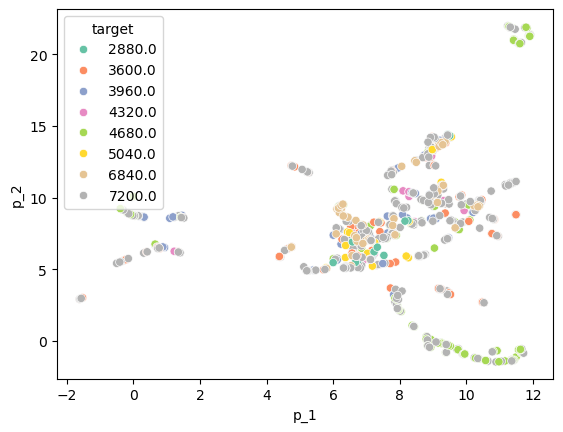

In [43]:
df_values = df_embedding.drop(columns=["target", "experimental_characteristics"])
nonlinear_instance = NonLinearReductions(dataset=df_values)

transform_values_umap = nonlinear_instance.applyUMAP()
transform_values_umap["target"] = df_embedding["target"].values

sns.scatterplot(data=transform_values_umap, x="p_1", y="p_2", hue="target", palette="Set2")


### Bert evaluation

In [ ]:
df_to_bert = df_data.copy()
df_to_bert["sequence"] = df_to_bert["sequence"].apply(lambda x: " ".join(x)) # this process is necessary for the application of the pre-trained model

bert_based = BertBasedMebedding(
    name_device="cuda",
    dataset=df_to_bert,
    name_model="Rostlab/prot_bert_bfd_ss3",
    name_tokenizer="Rostlab/prot_bert_bfd_ss3",
    column_seq="sequence",
    columns_ignore=["target", "experimental_characteristics"],
)

print("Loading model/tokenizer")
bert_based.load_model_tokenizer()

print("Generating embedding")
df_embedding = bert_based.embedding_process(batch_size=5)

bert_based.cleaning_memory()
print("Process finished")

df_embedding

Using device:  cuda
Loading model/tokenizer


KeyboardInterrupt: 

In [ ]:
df_values = df_embedding.drop(columns=["target", "experimental_characteristics"])
nonlinear_instance = NonLinearReductions(dataset=df_values)

transform_values_umap = nonlinear_instance.applyUMAP()
transform_values_umap["target"] = df_embedding["target"].values

sns.scatterplot(data=transform_values_umap, x="p_1", y="p_2", hue="target", palette="Set2")
